In [1]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("C:/Users/user/Downloads/Healthcare_Appointment_Analysis(raw data).csv")

In [4]:
df.head(10)

,patient_id,appointment_id,age,gender,scheduled_date,appointment_date,clinic,appointment_type,hypertension,diabetes,chronic_condition_count,previous_no_shows,sms_sent,insurance_type,distance_km,appointment_hour,attended,visit_cost_inr
0,P100001,A200001,51.0,Female,2025-11-19,2025-11-26,South Clinic,General Consultation,No,No,1,0,Yes,Employer,5.7,12,Yes,748.0
1,P100002,A200002,39.0,Female,2025-06-30,2025-07-13,West Clinic,General Consultation,No,No,0,0,Yes,Private,8.0,11,Yes,704.0
2,P100003,A200003,54.0,Female,2025-12-13,2025-12-28,Central Clinic,Dermatology,Yes,No,1,1,Yes,Self-Pay,20.9,14,Yes,754.0
3,P100004,A200004,71.0,Female,2025-07-11,2025-08-07,East Clinic,Dermatology,Yes,No,1,0,Yes,Government,3.8,14,Yes,736.0
4,P100005,A200005,38.0,Male,2025-09-03,2025-09-11,East Clinic,Follow-up,No,No,0,1,No,NaN,2.9,10,Yes,402.0
5,P100006,A200006,38.0,Female,2025-09-02,2025-09-21,South Clinic,General Consultation,No,No,1,0,No,Private,1.7,10,No,578.0
6,P100007,A200007,72.0,Female,2025-05-13,2025-05-21,North Clinic,Dermatology,No,No,0,0,Yes,Self-Pay,1.6,11,Yes,750.0
7,P100008,A200008,57.0,Male,2025-07-16,2025-08-16,North Clinic,Pediatrics,No,No,0,0,Yes,Employer,6.3,8,No,629.0
8,P100009,A200009,33.0,Female,2025-12-13,2025-12-27,East Clinic,General Consultation,No,No,0,0,Yes,Self-Pay,7.0,13,Yes,672.0
9,P100010,A200010,52.0,NaN,2025-02-18,2025-03-01,West Clinic,Follow-up,No,No,0,0,No,Private,8.9,14,No,448.0


In [5]:
df.shape

(10020, 18)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               10020 non-null  str    
 1   appointment_id           10020 non-null  str    
 2   age                      9920 non-null   float64
 3   gender                   9920 non-null   str    
 4   scheduled_date           10020 non-null  str    
 5   appointment_date         10020 non-null  str    
 6   clinic                   10020 non-null  str    
 7   appointment_type         10020 non-null  str    
 8   hypertension             10020 non-null  str    
 9   diabetes                 10020 non-null  str    
 10  chronic_condition_count  10020 non-null  int64  
 11  previous_no_shows        10020 non-null  int64  
 12  sms_sent                 9919 non-null   str    
 13  insurance_type           9919 non-null   str    
 14  distance_km              9920 non

In [7]:
df.duplicated().sum()

np.int64(20)

In [8]:
df = df.drop_duplicates()

df.shape

(10000, 18)

In [9]:
df.isnull().sum()  # missing values

patient_id                   0
appointment_id               0
age                        100
gender                     100
scheduled_date               0
appointment_date             0
clinic                       0
appointment_type             0
hypertension                 0
diabetes                     0
chronic_condition_count      0
previous_no_shows            0
sms_sent                   100
insurance_type             100
distance_km                100
appointment_hour             0
attended                     0
visit_cost_inr             100
dtype: int64

In [10]:
# Numerical columns
df['age'] = df['age'].fillna(df['age'].median())

df['distance_km'] = df['distance_km'].fillna(
    df['distance_km'].median()
)

In [11]:
# Categorical columns
df['gender'] = df['gender'].fillna(
    df['gender'].mode()[0]
)

df['sms_sent'] = df['sms_sent'].fillna('Unknown')

df['insurance_type'] = df['insurance_type'].fillna('Unknown')

In [12]:
# Visit cost - group-based median
df['visit_cost_inr'] = (
    df.groupby('appointment_type')['visit_cost_inr']
      .transform(lambda x: x.fillna(x.median()))
)

In [13]:
df.isnull().sum()

patient_id                 0
appointment_id             0
age                        0
gender                     0
scheduled_date             0
appointment_date           0
clinic                     0
appointment_type           0
hypertension               0
diabetes                   0
chronic_condition_count    0
previous_no_shows          0
sms_sent                   0
insurance_type             0
distance_km                0
appointment_hour           0
attended                   0
visit_cost_inr             0
dtype: int64

In [14]:
df['scheduled_date'] = pd.to_datetime(df['scheduled_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])

In [15]:
df[['scheduled_date', 'appointment_date']].dtypes

scheduled_date      datetime64[us]
appointment_date    datetime64[us]
dtype: object

In [16]:
#No of unique patients and appoinments
print("Unique Patients:", df['patient_id'].nunique())
print("Unique Appointments:", df['appointment_id'].nunique())

Unique Patients: 10000
Unique Appointments: 10000


In [17]:
df['patient_id'].duplicated().sum()

np.int64(0)

In [18]:
# waiting days
df['waiting_days'] = (
    df['appointment_date'] - df['scheduled_date']
).dt.days

df['waiting_days'].describe()

count    10000.000000
mean        10.988500
std          7.370197
min          0.000000
25%          5.000000
50%          9.000000
75%         15.000000
max         45.000000
Name: waiting_days, dtype: float64

In [ ]:
#Patient & Appointment Overview


In [19]:
df['gender'].value_counts()

gender
Female    5355
Male      4423
Other      222
Name: count, dtype: int64

In [20]:
import matplotlib.pyplot as plt

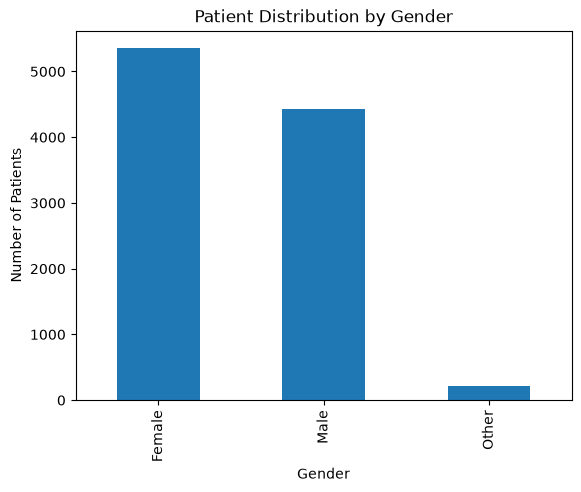

In [21]:
#distribution of patients by gender
df['gender'].value_counts().plot(
    kind='bar',
    title='Patient Distribution by Gender'
)

plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.show()

In [22]:
df['age'].describe()

count    10000.000000
mean        42.014300
std         18.600637
min          1.000000
25%         29.000000
50%         42.000000
75%         55.000000
max         90.000000
Name: age, dtype: float64

In [23]:
import seaborn as sns

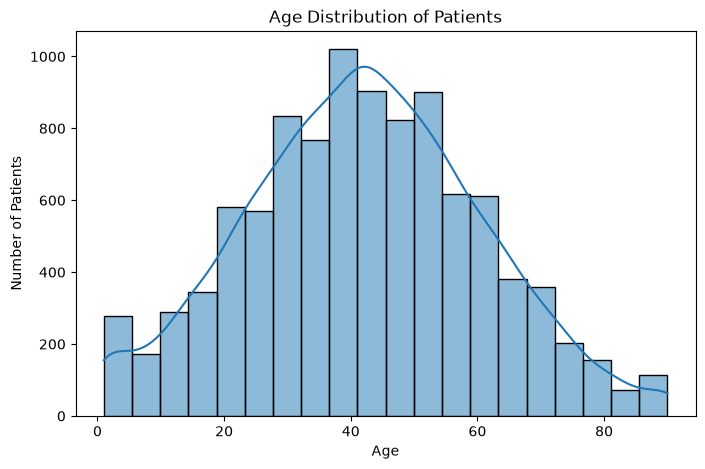

In [24]:
#age distribution of patients
plt.figure(figsize=(8,5))

sns.histplot(df['age'].dropna(), bins=20, kde=True)

plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')

plt.show()

In [25]:
#number of appointments by clinic
clinic_counts = df['clinic'].value_counts()

print(clinic_counts)

clinic
Central Clinic    2757
South Clinic      1977
North Clinic      1939
East Clinic       1745
West Clinic       1582
Name: count, dtype: int64


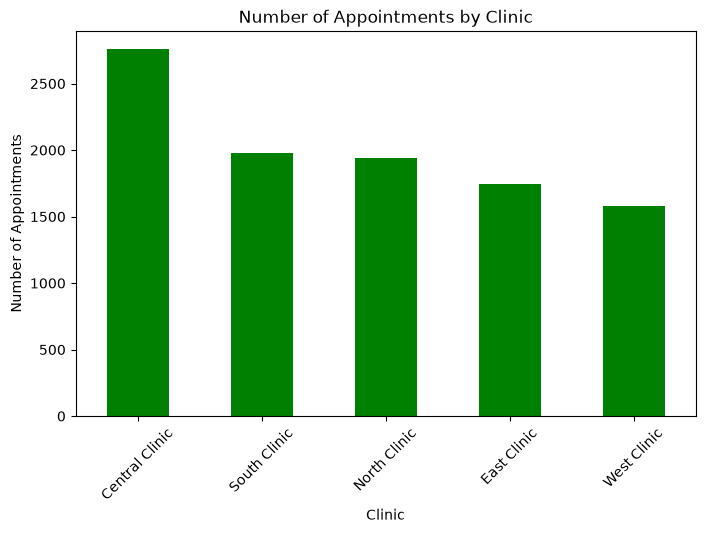

In [26]:
clinic_counts.plot(
    kind='bar',
    figsize=(8,5),color='green'
)
plt.xticks(rotation=45)
plt.title('Number of Appointments by Clinic')
plt.xlabel('Clinic')
plt.ylabel('Number of Appointments')

plt.show()

In [27]:
df['insurance_type'].value_counts()

insurance_type
Private       4106
Government    2969
Self-Pay      1598
Employer      1227
Unknown        100
Name: count, dtype: int64

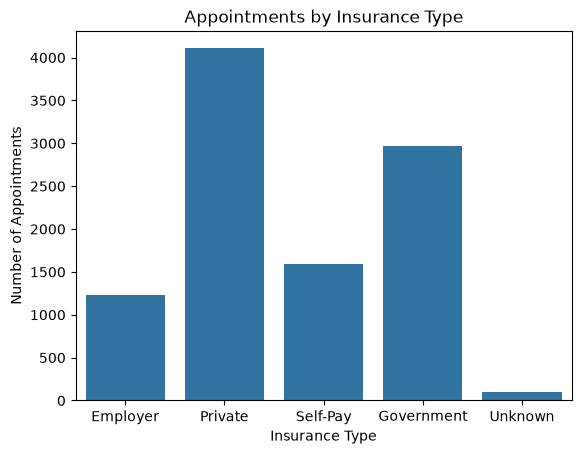

In [28]:
sns.countplot(
    data=df,
    x='insurance_type'
)

plt.title('Appointments by Insurance Type')
plt.xlabel('Insurance Type')
plt.ylabel('Number of Appointments')

plt.show()

In [ ]:
#Attendance Analysis

In [29]:
df['attended'].value_counts()

attended
Yes    7082
No     2918
Name: count, dtype: int64

In [30]:
attendance_rate = (
    df['attended'].eq('Yes').mean() * 100
)

print(f"Attendance Rate: {attendance_rate:.2f}%")

Attendance Rate: 70.82%


In [31]:
no_show_rate = (
    df['attended'].eq('No').mean() * 100
)

print(f"No-show Rate: {no_show_rate:.2f}%")

No-show Rate: 29.18%


In [32]:
clinic_attendance = (
    df.groupby('clinic')['attended']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=False)
)

print(clinic_attendance)

clinic
North Clinic      72.408458
West Clinic       71.618205
East Clinic       70.773639
Central Clinic    70.184984
South Clinic      69.549823
Name: attended, dtype: float64


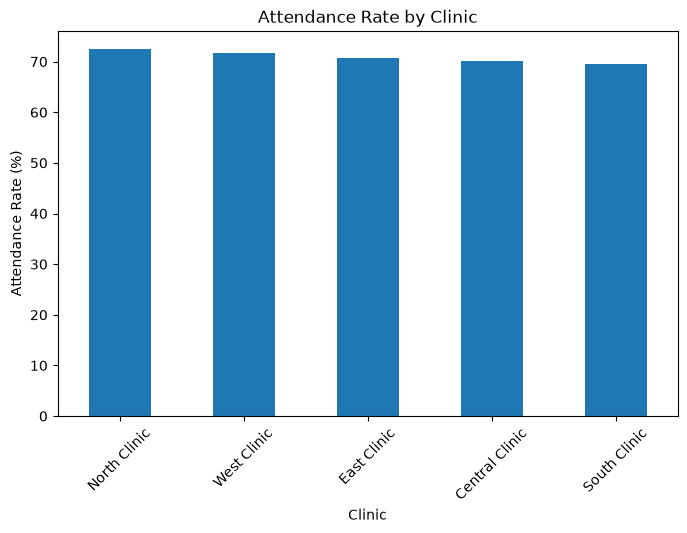

In [33]:
clinic_attendance.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Attendance Rate by Clinic')
plt.xlabel('Clinic')
plt.ylabel('Attendance Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [34]:
#No-Show Analysis
df.groupby('attended')['waiting_days'].mean()

attended
No     13.245716
Yes    10.058458
Name: waiting_days, dtype: float64

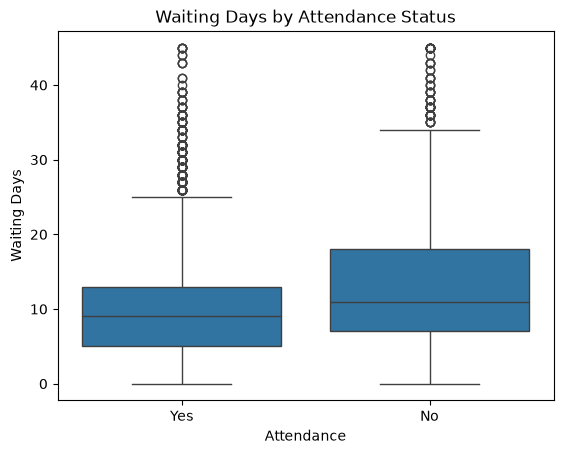

In [35]:
sns.boxplot(
    data=df,
    x='attended',
    y='waiting_days'
)

plt.title('Waiting Days by Attendance Status')
plt.xlabel('Attendance')
plt.ylabel('Waiting Days')

plt.show()

In [36]:
sms_attendance = pd.crosstab(
    df['sms_sent'],
    df['attended'],
    normalize='index'
) * 100

print(sms_attendance)

attended         No        Yes
sms_sent                      
No        33.711875  66.288125
Unknown   24.000000  76.000000
Yes       27.207392  72.792608


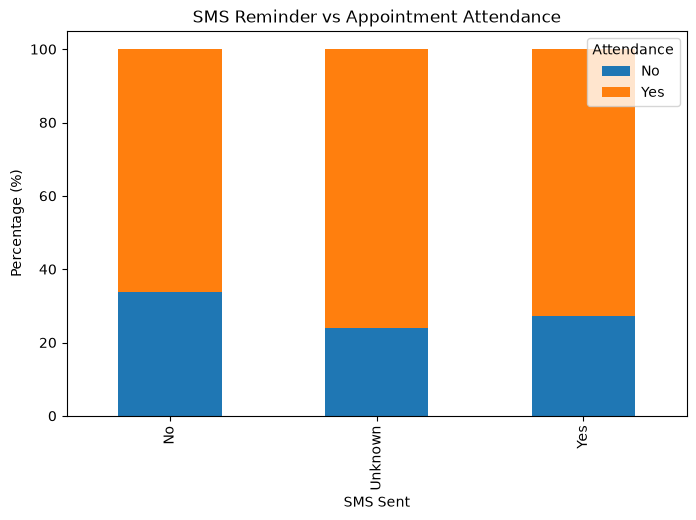

In [37]:
sms_attendance.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('SMS Reminder vs Appointment Attendance')
plt.xlabel('SMS Sent')
plt.ylabel('Percentage (%)')

plt.legend(title='Attendance')

plt.show()

In [38]:
#Which age group has the highest no-show rate?
bins = [0, 18, 30, 45, 60, 100]

labels = [
    '0-18',
    '19-30',
    '31-45',
    '46-60',
    '61+'
]

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

In [39]:
age_no_show = (
    df.groupby('age_group', observed=True)['attended']
      .apply(lambda x: (x == 'No').mean() * 100)
)

print(age_no_show)

age_group
0-18     29.759704
19-30    29.212792
31-45    29.301868
46-60    28.445298
61+      29.706601
Name: attended, dtype: float64


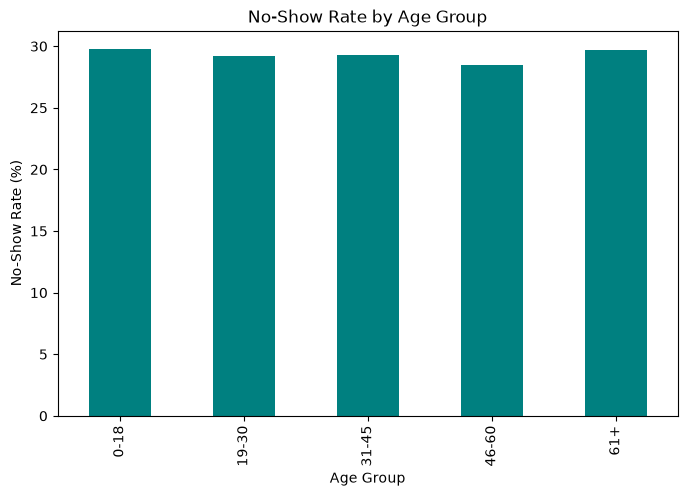

In [40]:
#No-show Rate by Age Group
age_no_show.plot(
    kind='bar',
    figsize=(8,5),color='teal'
)

plt.title('No-Show Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('No-Show Rate (%)')

plt.show()

In [41]:
#Does distance from the clinic differ between attendees and no-shows?
df.groupby('attended')['distance_km'].mean()

attended
No     7.332728
Yes    6.464036
Name: distance_km, dtype: float64

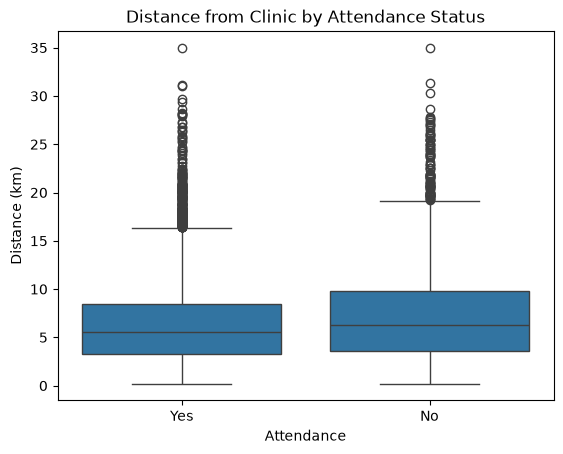

In [42]:
sns.boxplot(
    data=df,
    x='attended',
    y='distance_km'
)

plt.title('Distance from Clinic by Attendance Status')
plt.xlabel('Attendance')
plt.ylabel('Distance (km)')

plt.show()

In [47]:
#No-Show Rate by Clinic
no_show_by_clinic = (
    df.groupby('clinic')['attended']
      .apply(lambda x: (x == 'No').mean() * 100)
      .sort_values(ascending=False)
)

print(no_show_by_clinic)

clinic
South Clinic      30.450177
Central Clinic    29.815016
East Clinic       29.226361
West Clinic       28.381795
North Clinic      27.591542
Name: attended, dtype: float64


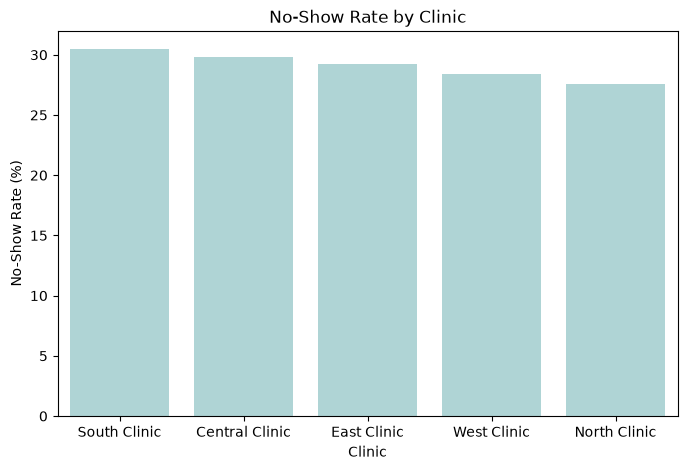

In [49]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=no_show_by_clinic.index,
    y=no_show_by_clinic.values,
    color='#A8DADC'
)

plt.title('No-Show Rate by Clinic')
plt.xlabel('Clinic')
plt.ylabel('No-Show Rate (%)')
plt.show()

In [ ]:
#Financial Analysis

In [50]:
df['visit_cost_inr'].describe()                                

count    10000.000000
mean       704.581000
std        274.258579
min        288.000000
25%        518.000000
50%        640.000000
75%        790.000000
max       1892.000000
Name: visit_cost_inr, dtype: float64

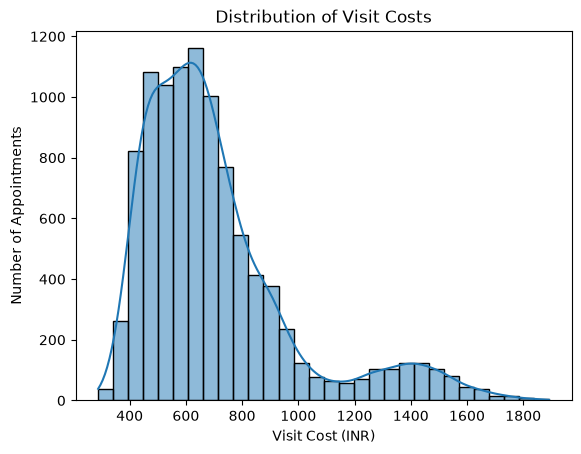

In [51]:
sns.histplot(
    df['visit_cost_inr'].dropna(),
    bins=30,
    kde=True
)

plt.title('Distribution of Visit Costs')
plt.xlabel('Visit Cost (INR)')
plt.ylabel('Number of Appointments')

plt.show()

In [52]:
avg_cost = (
    df.groupby('appointment_type')['visit_cost_inr']
      .mean()
      .sort_values(ascending=False)
)

print(avg_cost)

appointment_type
Cardiology              1386.956159
Dental                   894.119219
Dermatology              798.507502
General Consultation     650.238886
Pediatrics               554.412387
Follow-up                453.293566
Name: visit_cost_inr, dtype: float64


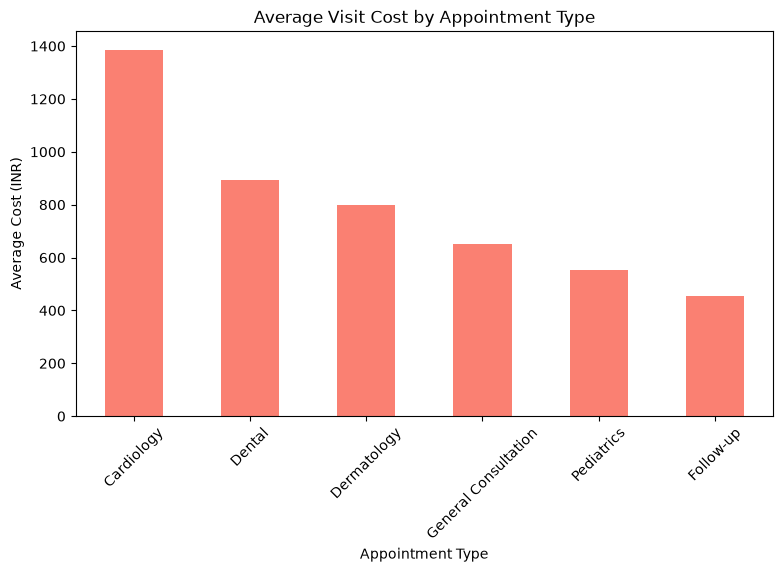

In [53]:
avg_cost.plot(
    kind='bar',
    figsize=(9,5),color='salmon'
)

plt.title('Average Visit Cost by Appointment Type')
plt.xlabel('Appointment Type')
plt.ylabel('Average Cost (INR)')

plt.xticks(rotation=45)

plt.show()

In [54]:
#Statistical Analysis
df['attended_flag'] = df['attended'].map({
    'Yes': 1,
    'No': 0
})

In [55]:
correlation = df[
    ['waiting_days', 'attended_flag']
].corr()

print(correlation)

               waiting_days  attended_flag
waiting_days       1.000000      -0.196599
attended_flag     -0.196599       1.000000


In [56]:
numeric_cols = [
    'age',
    'waiting_days',
    'previous_no_shows',
    'chronic_condition_count',
    'distance_km',
    'appointment_hour',
    'visit_cost_inr',
    'attended_flag'
]

In [57]:
correlation_matrix = df[numeric_cols].corr()

print(correlation_matrix)

                              age  waiting_days  previous_no_shows  \
age                      1.000000      0.012105          -0.008743   
waiting_days             0.012105      1.000000          -0.004227   
previous_no_shows       -0.008743     -0.004227           1.000000   
chronic_condition_count  0.004053      0.008060          -0.005566   
distance_km             -0.015530      0.004754          -0.017078   
appointment_hour         0.005011      0.014561          -0.008229   
visit_cost_inr           0.003254     -0.009837          -0.012136   
attended_flag            0.003722     -0.196599          -0.121577   

                         chronic_condition_count  distance_km  \
age                                     0.004053    -0.015530   
waiting_days                            0.008060     0.004754   
previous_no_shows                      -0.005566    -0.017078   
chronic_condition_count                 1.000000    -0.004061   
distance_km                            -0.00

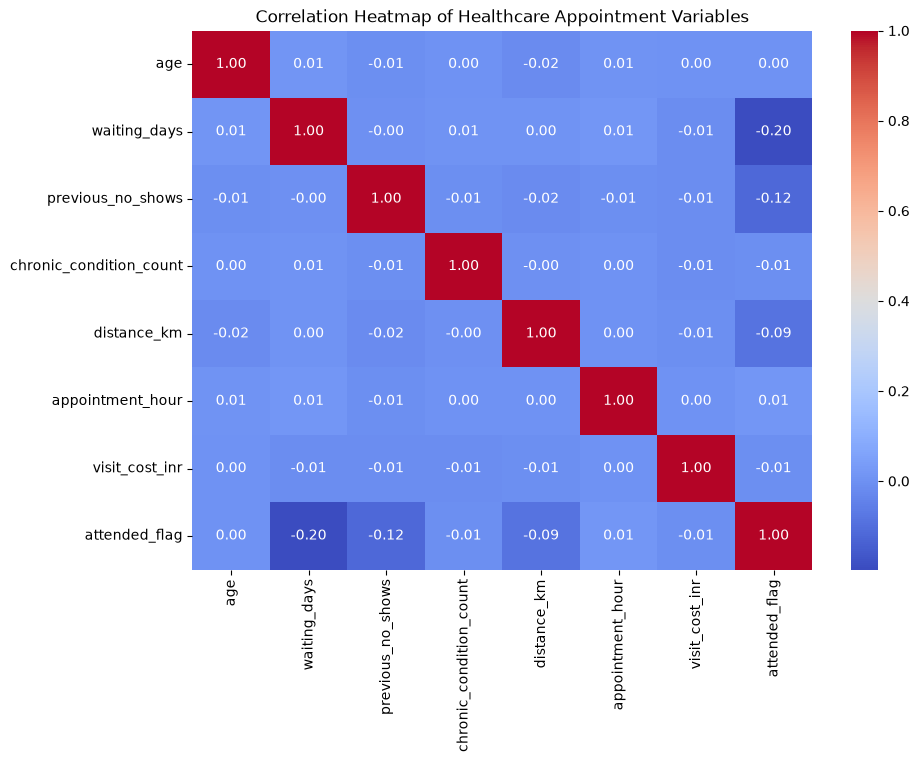

In [58]:
#Correlation Heatmap
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Healthcare Appointment Variables')

plt.show()